# Parallelization

LangGraph에서 여러 노드를 **동시에** 실행하는 방법을 배운다. Fan-out/Fan-in 패턴, Send API, Rate Limiting, 그리고 병렬 처리를 활용한 Voting 패턴까지 다룬다.

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## 병렬 처리가 필요한 이유

하나의 문서를 3개 관점(법률, 재무, 기술)으로 분석한다고 하자.

**순차 처리:**
```
법률 분석 (3초) → 재무 분석 (3초) → 기술 분석 (3초) = 총 9초
```

**병렬 처리:**
```
법률 분석 (3초) ─┐
재무 분석 (3초) ─┼→ 종합 = 총 3초 + α
기술 분석 (3초) ─┘
```

분석 관점이 서로 독립적이면 병렬로 실행해도 결과가 동일하다. LangGraph는 이런 병렬 실행을 **그래프 구조**로 자연스럽게 표현한다.

## 기본 병렬 노드 (Fan-out / Fan-in)

하나의 노드 뒤에 여러 노드를 연결하면 LangGraph가 자동으로 **병렬 실행**한다.

```
START → prepare ─→ legal_analysis  ─┐
                 ─→ financial_analysis ─┼→ summarize → END
                 ─→ technical_analysis ─┘
```

핵심: State에 `Annotated[list, operator.add]`를 사용해서 각 노드의 결과를 **하나의 리스트에 누적**한다.

In [2]:
import operator
import time
from typing import Annotated, TypedDict

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


class AnalysisState(TypedDict):
    document: str
    analyses: Annotated[list, operator.add]  # 각 분석 결과가 누적됨
    summary: str


def prepare(state: AnalysisState):
    """문서를 확인하고 분석을 시작한다."""
    print(f"[prepare] 문서 길이: {len(state['document'])}자")
    return {}


def legal_analysis(state: AnalysisState):
    result = llm.invoke(
        f"다음 문서를 법률 관점에서 핵심 리스크 2가지를 분석해줘. 간결하게.\n\n{state['document']}"
    )
    print("[legal_analysis] 완료")
    return {"analyses": [f"[법률] {result.content}"]}


def financial_analysis(state: AnalysisState):
    result = llm.invoke(
        f"다음 문서를 재무 관점에서 핵심 포인트 2가지를 분석해줘. 간결하게.\n\n{state['document']}"
    )
    print("[financial_analysis] 완료")
    return {"analyses": [f"[재무] {result.content}"]}


def technical_analysis(state: AnalysisState):
    result = llm.invoke(
        f"다음 문서를 기술 관점에서 핵심 포인트 2가지를 분석해줘. 간결하게.\n\n{state['document']}"
    )
    print("[technical_analysis] 완료")
    return {"analyses": [f"[기술] {result.content}"]}


def summarize(state: AnalysisState):
    all_analyses = "\n\n".join(state["analyses"])
    result = llm.invoke(
        f"다음 3가지 관점의 분석을 종합해서 3줄로 요약해줘:\n\n{all_analyses}"
    )
    return {"summary": result.content}

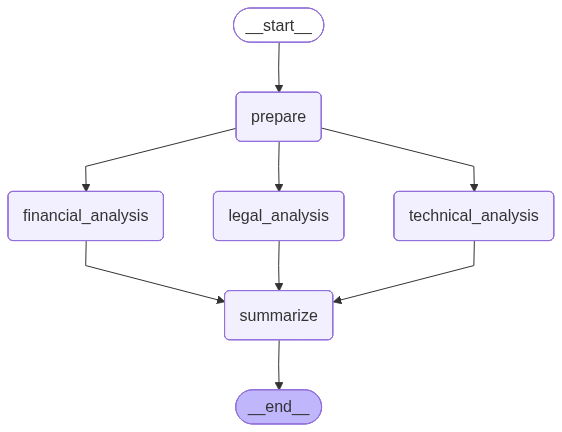

In [3]:
graph_builder = StateGraph(AnalysisState)

graph_builder.add_node("prepare", prepare)
graph_builder.add_node("legal_analysis", legal_analysis)
graph_builder.add_node("financial_analysis", financial_analysis)
graph_builder.add_node("technical_analysis", technical_analysis)
graph_builder.add_node("summarize", summarize)

# Fan-out: prepare → 3개 분석 노드 (병렬)
graph_builder.add_edge(START, "prepare")
graph_builder.add_edge("prepare", "legal_analysis")
graph_builder.add_edge("prepare", "financial_analysis")
graph_builder.add_edge("prepare", "technical_analysis")

# Fan-in: 3개 분석 노드 → summarize
graph_builder.add_edge("legal_analysis", "summarize")
graph_builder.add_edge("financial_analysis", "summarize")
graph_builder.add_edge("technical_analysis", "summarize")
graph_builder.add_edge("summarize", END)

analysis_graph = graph_builder.compile()
display(Image(analysis_graph.get_graph().draw_mermaid_png()))

In [4]:
document = """AI 스타트업 A사가 시리즈B 투자 500억원을 유치했다.
핵심 기술은 자체 개발한 경량 LLM으로, 기존 모델 대비 추론 속도가 3배 빠르다.
다만 학습 데이터의 저작권 문제가 일부 제기되고 있으며,
현재 매출 대비 기업가치가 100배 수준이라는 지적도 있다.
올해 하반기 상용화를 목표로 하고 있다."""

start = time.time()
result = analysis_graph.invoke({"document": document})
elapsed = time.time() - start

print(f"\n소요 시간: {elapsed:.1f}초")
print(f"\n=== 분석 결과 ({len(result['analyses'])}개) ===")
for a in result["analyses"]:
    print(a)
    print()
print(f"=== 종합 ===")
print(result["summary"])

[prepare] 문서 길이: 169자
[legal_analysis] 완료
[financial_analysis] 완료
[technical_analysis] 완료

소요 시간: 10.2초

=== 분석 결과 (3개) ===
[재무] 1. **투자 유치와 기업가치**: A사는 시리즈B에서 500억원을 유치했지만, 현재 매출 대비 기업가치가 100배에 달하는 것은 과대평가 우려를 나타내며, 이는 향후 투자자들에게 리스크 요소로 작용할 수 있다.

2. **기술 경쟁력과 저작권 문제**: 경량 LLM의 빠른 추론 속도는 시장에서의 경쟁력을 높일 수 있지만, 학습 데이터의 저작권 문제가 해결되지 않으면 상용화 과정에서 법적 리스크가 발생할 수 있어 재무적 안정성에 부정적인 영향을 미칠 수 있다.

[법률] 1. **저작권 리스크**: A사가 사용하는 학습 데이터에 대한 저작권 문제가 제기되고 있어, 이는 향후 법적 분쟁이나 손해배상 청구로 이어질 수 있다. 저작권 침해가 확인될 경우, 기술의 상용화 및 기업의 지속 가능성에 심각한 영향을 미칠 수 있다.

2. **기업가치 평가 리스크**: 현재 매출 대비 기업가치가 100배에 달하는 것은 과도한 평가로 간주될 수 있으며, 이는 투자자들에게 신뢰를 잃게 할 수 있다. 상용화에 실패하거나 예상보다 낮은 성과를 보일 경우, 기업가치가 급락할 위험이 존재한다.

[기술] 1. **경량 LLM 기술**: A사는 자체 개발한 경량 LLM을 통해 기존 모델보다 3배 빠른 추론 속도를 제공, 이는 시장에서의 경쟁력을 높일 수 있는 중요한 기술적 우위로 작용할 가능성이 있다.

2. **저작권 문제 및 기업가치**: 학습 데이터의 저작권 문제는 기술 상용화에 있어 법적 리스크를 초래할 수 있으며, 현재 매출 대비 100배의 기업가치는 투자자들에게 과도한 평가로 인식될 수 있어 향후 성장 가능성에 대한 우려를 낳을 수 있다.

=== 종합 ===
A사는 시리즈B에서 500억원을 유치했지만, 현재 매출 대비 100배의 기업가치는 과대평가

- `prepare`에서 3개 노드로 **Fan-out** — 같은 출발 노드에서 여러 엣지를 연결하면 된다
- 3개 노드에서 `summarize`로 **Fan-in** — LangGraph가 **모든 선행 노드가 완료될 때까지 대기**한 후 실행한다
- `Annotated[list, operator.add]` 덕분에 각 노드의 결과가 하나의 리스트에 모인다
- 병렬 노드는 동시에 실행되므로 **결과가 리스트에 들어가는 순서는 보장되지 않는다** — 순서가 중요하면 결과에 식별자를 포함시키거나 후처리에서 정렬해야 한다
- 노드 함수가 일반 `def`이고 `invoke`(동기)로 실행해도 **병렬 처리가 된다**. LangGraph는 내부적으로 비동기 런타임 위에서 동작하기 때문에, 그래프 구조상 동시에 실행 가능한 노드는 자동으로 병렬 실행한다. `async def` + `ainvoke`는 노드 안에서 `await`나 `Semaphore` 같은 비동기 기능을 직접 사용할 때만 필요하다.

### 결과 순서가 필요할 때

병렬 노드의 결과는 어떤 노드가 먼저 끝나느냐에 따라 순서가 달라진다. 순서가 중요하면 결과에 **식별자를 포함**시키고 후처리에서 정렬하면 된다.

위 예제의 분석 노드를 수정해서, 결과를 `(순서, 내용)` 튜플로 반환하고 `summarize`에서 정렬하는 방식이다.

In [ ]:
class OrderedAnalysisState(TypedDict):
    document: str
    analyses: Annotated[list, operator.add]  # (순서, 내용) 튜플이 누적됨
    summary: str


def ordered_legal(state: OrderedAnalysisState):
    result = llm.invoke(
        f"다음 문서를 법률 관점에서 핵심 리스크 2가지를 분석해줘. 간결하게.\n\n{state['document']}"
    )
    return {"analyses": [(0, f"[법률] {result.content}")]}


def ordered_financial(state: OrderedAnalysisState):
    result = llm.invoke(
        f"다음 문서를 재무 관점에서 핵심 포인트 2가지를 분석해줘. 간결하게.\n\n{state['document']}"
    )
    return {"analyses": [(1, f"[재무] {result.content}")]}


def ordered_technical(state: OrderedAnalysisState):
    result = llm.invoke(
        f"다음 문서를 기술 관점에서 핵심 포인트 2가지를 분석해줘. 간결하게.\n\n{state['document']}"
    )
    return {"analyses": [(2, f"[기술] {result.content}")]}


def ordered_summarize(state: OrderedAnalysisState):
    # 순서대로 정렬
    sorted_analyses = sorted(state["analyses"], key=lambda x: x[0])
    print("정렬된 순서:")
    for order, content in sorted_analyses:
        print(f"  {order}: {content[:30]}...")

    all_analyses = "\n\n".join(content for _, content in sorted_analyses)
    result = llm.invoke(
        f"다음 3가지 관점의 분석을 종합해서 3줄로 요약해줘:\n\n{all_analyses}"
    )
    return {"summary": result.content}


graph_builder = StateGraph(OrderedAnalysisState)
graph_builder.add_node("legal", ordered_legal)
graph_builder.add_node("financial", ordered_financial)
graph_builder.add_node("technical", ordered_technical)
graph_builder.add_node("summarize", ordered_summarize)

graph_builder.add_edge(START, "legal")
graph_builder.add_edge(START, "financial")
graph_builder.add_edge(START, "technical")
graph_builder.add_edge("legal", "summarize")
graph_builder.add_edge("financial", "summarize")
graph_builder.add_edge("technical", "summarize")
graph_builder.add_edge("summarize", END)

ordered_graph = graph_builder.compile()

result = ordered_graph.invoke({"document": document})
print(f"\n=== 종합 ===")
print(result["summary"])

  1: [재무] 1. **투자 유치와 기업가치**: A사는 시...
  0: [법률] 1. **저작권 리스크**: A사가 사용하는 ...
  2: [기술] 1. **경량 LLM 기술**: A사는 자체 ...
정렬된 순서:
  0: [법률] 1. **저작권 리스크**: A사가 사용하는 ...
  1: [재무] 1. **투자 유치와 기업가치**: A사는 시...
  2: [기술] 1. **경량 LLM 기술**: A사는 자체 ...

=== 종합 ===
A사는 저작권 리스크로 인해 법적 분쟁 가능성이 있으며, 이는 기업 운영과 상용화에 부정적인 영향을 미칠 수 있다. 현재 매출 대비 100배에 달하는 기업가치는 과대평가 우려를 낳아 투자자 신뢰를 저하시킬 수 있으며, 상용화 실패 시 추가 자금 조달에 어려움을 겪을 수 있다. 그러나 경량 LLM 기술은 빠른 추론 속도로 경쟁력을 높일 수 있는 잠재력을 지니고 있지만, 저작권 문제는 여전히 해결해야 할 중요한 과제로 남아 있다.


## Send API (동적 병렬)

Fan-out/Fan-in은 **컴파일 시점에** 병렬 노드가 고정된다. 하지만 실행 시점에 병렬 태스크 수가 달라져야 하는 경우가 있다.

예시:
- 사용자가 분석할 주제를 1개 줄 수도, 5개 줄 수도 있다
- 검색 결과 수에 따라 병렬 처리할 문서 수가 달라진다

`Send` API는 **런타임에 동적으로** 병렬 노드를 생성한다. 데이터를 나눠서 병렬 처리하고 결과를 합친다는 흐름은 Fan-out/Fan-in과 같지만, **병렬 수가 실행 시점에 결정**된다는 점이 다르다.

`Send(노드이름, state)`를 호출하면 해당 노드의 새 인스턴스를 만들고, 두 번째 인자를 그 노드의 **독립적인 입력 State**로 전달한다. 그래서 병렬 노드용 State(`AnalyzeTopicState`)를 별도로 정의한다 — 그래프 전체 State(`SendState`)와 구분하기 위해서다.

앞에서 `add_conditional_edges`에 전달하는 라우팅 함수는 문자열(노드 이름)을 반환해서 **라우팅**에 사용했다. 여기서는 라우팅 함수가 `Send` 객체를 반환하는데, 이렇게 하면 **동적 병렬**이 된다.

`add_conditional_edges(시작노드, 라우팅함수, 목적지)` — 세 번째 인자는 **가능한 목적지 노드**를 명시한다. 딕셔너리(`{"반환값": "노드이름"}`)나 리스트(`["노드이름"]`) 모두 가능하다. Send는 런타임에 목적지를 결정하기 때문에, 컴파일 시점에 어떤 노드로 갈 수 있는지 명시해줘야 그래프를 구성할 수 있다.

In [7]:
from langgraph.types import Send


class SendState(TypedDict):
    topics: list[str]  # 분석할 주제 목록
    results: Annotated[list, operator.add]  # 분석 결과 누적
    final_report: str


class AnalyzeTopicState(TypedDict):
    """개별 분석 태스크의 입력 State"""
    topic: str


def generate_tasks(state: SendState):
    """주제 목록을 기반으로 병렬 태스크를 동적 생성한다."""
    return [
        Send("analyze_topic", {"topic": topic})
        for topic in state["topics"]
    ]


def analyze_topic(state: AnalyzeTopicState):
    topic = state["topic"]
    result = llm.invoke(f"'{topic}'에 대해 핵심 트렌드를 2문장으로 분석해줘.")
    print(f"[analyze_topic] '{topic}' 완료")
    # AnalyzeTopicState가 아닌 부모 State(SendState)의 results에 병합된다
    return {"results": [f"[{topic}] {result.content}"]}


def make_report(state: SendState):
    all_results = "\n\n".join(state["results"])
    result = llm.invoke(
        f"다음 분석 결과들을 종합해서 보고서 형태로 요약해줘:\n\n{all_results}"
    )
    return {"final_report": result.content}

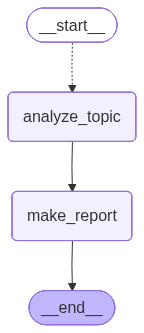

In [8]:
graph_builder = StateGraph(SendState)

graph_builder.add_node("analyze_topic", analyze_topic)
graph_builder.add_node("make_report", make_report)

# generate_tasks가 Send 객체 리스트를 반환 → 동적 Fan-out
graph_builder.add_conditional_edges(START, generate_tasks, ["analyze_topic"])
graph_builder.add_edge("analyze_topic", "make_report")
graph_builder.add_edge("make_report", END)

send_graph = graph_builder.compile()
display(Image(send_graph.get_graph().draw_mermaid_png()))

In [10]:
# 주제 3개
result = send_graph.invoke({"topics": ["생성형 AI", "자율주행", "양자컴퓨팅"]})
print(f"분석 수: {len(result['results'])}개")
print(f"\n=== 보고서 ===")
print(result["final_report"])

[analyze_topic] '자율주행' 완료
[analyze_topic] '생성형 AI' 완료
[analyze_topic] '양자컴퓨팅' 완료
분석 수: 3개

=== 보고서 ===
# 기술 발전 보고서

## 1. 생성형 AI
생성형 AI는 자연어 처리, 이미지 생성, 음악 작곡 등 다양한 분야에서 창의적인 콘텐츠를 자동으로 생성하는 기술로, 사용자 맞춤형 경험을 제공하는 데 중요한 역할을 하고 있습니다. 최근에는 이 기술의 윤리적 문제와 데이터 편향성에 대한 논의가 활발해지면서, AI의 책임 있는 사용과 규제 필요성이 강조되고 있습니다. 이러한 논의는 생성형 AI의 발전과 함께 사회적 수용성을 높이는 데 기여할 것으로 기대됩니다.

## 2. 자율주행
자율주행 기술은 인공지능과 센서 기술의 발전에 힘입어 점점 더 안전하고 효율적인 교통 시스템을 구현하고 있습니다. 다양한 기업과 스타트업들이 자율주행 차량의 상용화를 위해 협력하고 있으며, 이는 미래의 모빌리티 패러다임을 변화시키고 있습니다. 자율주행 기술의 발전은 교통사고 감소, 교통 혼잡 완화 등 사회적 이익을 가져올 것으로 예상됩니다.

## 3. 양자컴퓨팅
양자컴퓨팅은 기존의 클래식 컴퓨터로는 해결하기 어려운 복잡한 문제를 빠르게 처리할 수 있는 가능성으로 주목받고 있습니다. 특히 화학, 물리학, 최적화 문제 등 다양한 분야에서 혁신적인 응용이 기대되고 있습니다. 최근에는 양자 알고리즘의 발전과 함께 상용화에 대한 연구가 활발히 진행되고 있으며, 주요 기술 기업들이 양자 하드웨어 및 소프트웨어 생태계를 구축하기 위해 경쟁하고 있습니다. 이는 향후 기술 혁신과 산업 발전에 큰 영향을 미칠 것으로 보입니다.

## 결론
위의 세 가지 기술은 각각의 분야에서 혁신적인 발전을 이루고 있으며, 사회와 산업에 미치는 영향이 큽니다. 생성형 AI는 사용자 경험을 향상시키는 동시에 윤리적 문제를 해결해야 할 과제가 있으며, 자율주행 기술은 교통 시스템의 안전성과 효율성을 높이는 데 기여하고 있습니다. 양자컴퓨팅은 

- `Send(노드이름, state)`로 해당 노드의 **새 인스턴스**를 동적으로 생성한다
- `generate_tasks` 함수가 `Send` 객체의 리스트를 반환하면, 리스트 길이만큼 병렬 실행된다
- `add_conditional_edges`의 세 번째 인자 `["analyze_topic"]`은 **가능한 목적지 노드 목록**이다. Send는 런타임에 목적지를 결정하기 때문에 컴파일 시점에 어떤 노드로 갈 수 있는지 명시해줘야 그래프를 구성할 수 있다
- Fan-out과 달리 **런타임에 병렬 수가 결정**된다
- 결과 리스트의 순서는 보장되지 않는다 — 순서가 중요하면 결과에 식별자를 포함시키거나 후처리에서 정렬해야 한다
- `AnalyzeTopicState`는 Send가 전달하는 **입력 스펙**이다. `analyze_topic` 노드가 반환한 `{"results": [...]}`는 `AnalyzeTopicState`에 저장되는 게 아니라, 키 이름이 같은 **부모 State(`SendState`)의 `results`에 자동으로 병합**된다
- 병렬 노드 중 하나가 예외를 발생시키면 **그래프 전체가 실패**한다 — 안정성이 중요하면 노드 내부에서 try/except로 에러를 처리해야 한다

## Rate Limiting

**Rate Limit**은 API 제공자가 일정 시간 내 요청 수를 제한하는 정책이다. 예를 들어 OpenAI API는 분당 요청 수(RPM)와 분당 토큰 수(TPM)에 상한을 두고, 이를 초과하면 `429 Too Many Requests` 에러를 반환한다. 병렬 처리로 동시에 많은 요청을 보내면 이 제한에 걸리기 쉽다.

`asyncio.Semaphore`로 **동시 실행 수를 제한**해서 Rate Limit을 회피할 수 있다.

`Semaphore`는 동시에 접근할 수 있는 수를 제한하는 동기화 도구다. `Semaphore(3)`이면 동시에 3개까지만 실행을 허용하고, 나머지는 자리가 날 때까지 대기한다. `async with semaphore:` 블록에 들어갈 때 자리를 하나 차지하고, 블록을 나올 때 자리를 반환한다.

시나리오: 8개 주제를 분석해야 하지만, LLM API가 동시에 3개까지만 허용하는 상황.

비동기 노드를 사용하므로 `async def`로 노드를 정의하고, 그래프 실행 시 `ainvoke`를 사용한다. `ainvoke`는 `invoke`의 비동기 버전으로, `await`와 함께 사용한다. Jupyter 노트북은 이미 이벤트 루프가 실행 중이라 셀에서 `await`를 바로 쓸 수 있다.

아래 코드에서 `semaphore`를 모듈 레벨에 선언하고, 노드 함수 안에서 클로저로 참조한다. 노드 함수가 호출될 때마다 같은 세마포어를 공유하기 때문에 동시 실행 수 제한이 작동한다.

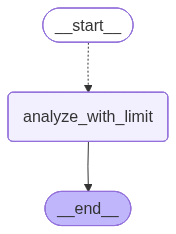

In [11]:
import asyncio

# asyncio.Semaphore로 동시 호출 수 제한
semaphore = asyncio.Semaphore(3)  # 동시 최대 3개


class RateLimitState(TypedDict):
    topics: list[str]
    results: Annotated[list, operator.add]


class RateLimitItemState(TypedDict):
    topic: str


def dispatch_topics(state: RateLimitState):
    return [
        Send("analyze_with_limit", {"topic": topic})
        for topic in state["topics"]
    ]


async def analyze_with_limit(state: RateLimitItemState):
    topic = state["topic"]
    async with semaphore:
        print(f"[시작] {topic} (현재 동시 실행 중)")
        result = await llm.ainvoke(f"'{topic}'에 대해 한 문장으로 설명해줘.")
        print(f"[완료] {topic}")
        return {"results": [f"[{topic}] {result.content}"]}


graph_builder = StateGraph(RateLimitState)
graph_builder.add_node("analyze_with_limit", analyze_with_limit)

graph_builder.add_conditional_edges(START, dispatch_topics, ["analyze_with_limit"])
graph_builder.add_edge("analyze_with_limit", END)

rate_limit_graph = graph_builder.compile()
display(Image(rate_limit_graph.get_graph().draw_mermaid_png()))

In [12]:
topics = ["AI", "블록체인", "IoT", "클라우드", "5G", "메타버스", "드론", "AR/VR"]

result = await rate_limit_graph.ainvoke({"topics": topics})

print(f"총 {len(topics)}개 주제, 동시 최대 3개 제한")
print(f"\n=== 결과 ===")
for r in result["results"]:
    print(r)

[시작] AI (현재 동시 실행 중)
[시작] 블록체인 (현재 동시 실행 중)
[시작] IoT (현재 동시 실행 중)
[완료] IoT
[시작] 클라우드 (현재 동시 실행 중)
[완료] 블록체인
[시작] 5G (현재 동시 실행 중)
[완료] AI
[시작] 메타버스 (현재 동시 실행 중)
[완료] 클라우드
[시작] 드론 (현재 동시 실행 중)
[완료] 5G
[시작] AR/VR (현재 동시 실행 중)
[완료] 메타버스
[완료] 드론
[완료] AR/VR
총 8개 주제, 동시 최대 3개 제한

=== 결과 ===
[AI] AI(인공지능)는 인간의 지능을 모방하여 학습, 문제 해결, 의사결정 등을 수행하는 컴퓨터 시스템이나 소프트웨어를 의미합니다.
[블록체인] 블록체인은 데이터를 안전하게 저장하고 관리하기 위해 분산된 네트워크에서 거래 기록을 암호화하여 연결된 블록 형태로 저장하는 기술입니다.
[IoT] IoT(사물인터넷)는 인터넷에 연결된 다양한 기기들이 서로 데이터를 수집하고 교환하여 자동화된 서비스를 제공하는 기술입니다.
[클라우드] 클라우드는 인터넷을 통해 데이터 저장, 관리 및 처리 서비스를 제공하는 기술로, 사용자가 물리적 하드웨어 없이도 필요한 리소스를 유연하게 이용할 수 있게 해줍니다.
[5G] 5G는 초고속 데이터 전송, 낮은 지연 시간, 그리고 대규모 연결성을 제공하는 차세대 이동통신 기술입니다.
[메타버스] 메타버스는 가상 현실과 증강 현실을 포함한 디지털 공간에서 사용자들이 상호작용하고 경험을 공유할 수 있는 3차원 가상 세계를 의미합니다.
[드론] 드론은 원격 조정 또는 자율 비행 기능을 갖춘 무인 항공기로, 다양한 용도로 사용됩니다.
[AR/VR] AR/VR은 증강 현실(AR)과 가상 현실(VR) 기술을 통해 사용자가 현실 세계와 가상 세계를 상호작용하며 몰입할 수 있는 경험을 제공하는 기술입니다.


핵심 포인트:

- `asyncio.Semaphore(N)`으로 동시 실행 수를 N개로 제한한다
- 노드 함수를 `async def`로 정의하고, `async with semaphore:` 블록 안에서 LLM 호출한다
- 그래프 실행 시 `ainvoke`(비동기)를 사용한다
- API Rate Limit 대응뿐 아니라, 메모리/CPU 사용량 제어에도 활용 가능하다

## Voting 패턴

하나의 질문에 대해 **여러 LLM 응답을 동시에 생성**하고, 그 중 최선의 답변을 선택하는 패턴이다.

```
             ┌→ generate_1 ─┐
START → fan_out → generate_2 ─┼→ vote → END
             └→ generate_3 ─┘
```

같은 모델이라도 Temperature를 높이면 다른 답변이 나온다. 이 다양성을 활용해서 품질을 높이는 전략이다. 같은 모델 대신 서로 다른 모델(GPT-4o, Claude, Gemini 등)을 동시에 호출하는 방식도 가능하다. 평가(judge)용 LLM은 정확한 판단이 중요하므로, 생성용보다 고급 모델을 쓰면 효과적이다.

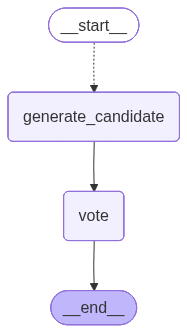

In [13]:
from pydantic import BaseModel, Field


# 다양한 답변을 생성하기 위해 Temperature를 높인 LLM
creative_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.9)
# 평가용 LLM은 일관성을 위해 Temperature=0
judge_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


class VotingState(TypedDict):
    question: str
    candidates: Annotated[list, operator.add]  # 후보 답변 누적
    best_answer: str


class VoteItemState(TypedDict):
    question: str
    candidate_id: int


def generate_candidate(state: VoteItemState):
    """후보 답변을 하나 생성한다."""
    result = creative_llm.invoke(
        f"다음 질문에 창의적이고 유용하게 답변해줘:\n\n{state['question']}"
    )
    candidate_id = state["candidate_id"]
    print(f"[후보 {candidate_id}] 생성 완료")
    return {"candidates": [{"id": candidate_id, "answer": result.content}]}


class VoteResult(BaseModel):
    """투표 결과"""
    best_id: int = Field(description="가장 좋은 답변의 ID (0부터 시작)")
    reason: str = Field(description="선택 이유")


def vote(state: VotingState):
    """후보 답변들 중 최선을 선택한다."""
    candidates = state["candidates"]

    candidates_text = ""
    for c in candidates:
        candidates_text += f"\n--- 후보 {c['id']} ---\n{c['answer']}\n"

    judge = judge_llm.with_structured_output(VoteResult)
    result = judge.invoke(
        f"다음 질문에 대한 여러 답변 후보가 있다. 가장 정확하고 유용한 답변을 골라줘.\n\n"
        f"질문: {state['question']}\n\n"
        f"후보 답변들:{candidates_text}\n\n"
        f"가장 좋은 답변의 ID와 이유를 알려줘."
    )

    best = next(c for c in candidates if c["id"] == result.best_id)
    print(f"\n[투표 결과] 후보 {result.best_id} 선택 — {result.reason}")
    return {"best_answer": best["answer"]}


def fan_out_candidates(state: VotingState):
    """N개의 후보 답변을 병렬 생성한다."""
    n_candidates = 3
    return [
        Send("generate_candidate", {
            "question": state["question"],
            "candidate_id": i,
        })
        for i in range(n_candidates)
    ]


# 그래프 구성
voting_builder = StateGraph(VotingState)
voting_builder.add_node("generate_candidate", generate_candidate)
voting_builder.add_node("vote", vote)

voting_builder.add_conditional_edges(START, fan_out_candidates, ["generate_candidate"])
voting_builder.add_edge("generate_candidate", "vote")
voting_builder.add_edge("vote", END)

voting_graph = voting_builder.compile()
display(Image(voting_graph.get_graph().draw_mermaid_png()))

In [ ]:
result = voting_graph.invoke({
    "question": "프로그래밍을 처음 배우는 사람에게 파이썬을 추천하는 이유를 설명해줘"
})

print("=== 후보 답변들 ===")
for c in result["candidates"]:
    print(f"\n[후보 {c['id']}] {c['answer'][:150]}...")

print(f"\n=== 최종 선택 ===")
print(result["best_answer"])

[후보 0] 생성 완료
[후보 1] 생성 완료
[후보 2] 생성 완료

[투표 결과] 후보 1 선택 — 후보 1은 파이썬을 추천하는 이유를 명확하고 체계적으로 설명하고 있으며, 초보자가 이해하기 쉬운 문법, 다양한 활용성, 강력한 커뮤니티, 유연성과 확장성, 코딩 사고 방식의 기초 다지기, 실습 중심의 학습, 재미와 창의성 유도 등 여러 측면을 포괄적으로 다루고 있습니다. 또한, 각 항목이 구체적이고 실용적인 예시를 통해 뒷받침되어 있어, 초보자에게 매우 유용한 정보를 제공합니다.
=== 후보 답변들 ===

[후보 0] 프로그래밍을 처음 배우는 사람에게 파이썬을 추천하는 이유는 여러 가지가 있습니다. 다음은 그 중 몇 가지입니다:

1. **간결하고 읽기 쉬운 문법**: 파이썬은 코드가 직관적이고 시각적으로 깔끔합니다. 다른 프로그래밍 언어와 비교했을 때, 괄호나 세미콜론 같은 문법적...

[후보 1] 프로그래밍을 처음 배우는 사람에게 파이썬을 추천하는 이유는 여러 가지가 있습니다. 그 중에서도 특히 다음과 같은 점들이 매력적입니다:

1. **간결하고 읽기 쉬운 문법**: 파이썬은 영어에 가까운 문법을 가지고 있어, 코드가 직관적이고 이해하기 쉽습니다. 복잡한 기호...

[후보 2] 프로그래밍을 처음 배우는 사람에게 파이썬을 추천하는 이유는 여러 가지가 있습니다. 다음은 그 중 몇 가지를 창의적이고 유용하게 정리해 보았습니다.

1. **읽기 쉬운 문법**: 파이썬은 마치 영어로 글을 쓰는 것처럼 간결하고 명확한 문법을 가지고 있습니다. 이는 초보...

=== 최종 선택 ===
프로그래밍을 처음 배우는 사람에게 파이썬을 추천하는 이유는 여러 가지가 있습니다. 그 중에서도 특히 다음과 같은 점들이 매력적입니다:

1. **간결하고 읽기 쉬운 문법**: 파이썬은 영어에 가까운 문법을 가지고 있어, 코드가 직관적이고 이해하기 쉽습니다. 복잡한 기호나 구문을 최소화하여, 처음 배우는 사람도 쉽게 접근할 수 있습니다.

2. **광범위한 활용성**: 파이썬은 

: 

- **Temperature를 높여서** 다양한 후보를 생성한다 (다양성이 핵심)
- **Judge LLM**은 Temperature=0으로 일관된 평가를 한다
- `with_structured_output`으로 투표 결과를 구조화한다
- Send API로 후보 수를 동적으로 조절할 수 있다 (3개 → 5개 등)
- **활용 예시**: 마케팅 카피 생성, 코드 생성, 번역 등 품질 변동이 큰 작업에서 최선의 결과를 뽑아낸다

## 병렬 처리는 언제 쓰는가

병렬 처리가 **적합한 경우**:
- 독립적인 작업 여러 개를 동시에 처리하여 속도를 높이고 싶을 때
- 동일 문서를 여러 관점으로 동시 분석 후 종합
- 여러 URL을 병렬 크롤링 후 결과 합치기
- 하나의 질문에 대해 여러 LLM 응답을 생성하고 최선을 선택 (Voting)

**주의가 필요한 경우**:
- 작업 간에 의존성이 있을 때 (B가 A의 결과를 필요로 함) → 병렬 처리 불가, 순차 실행해야 한다
- 병렬 작업 수가 많아 Rate Limit에 걸릴 수 있을 때 → Semaphore로 동시 실행 수를 제어
- 결과의 순서가 중요할 때 → 결과에 식별자를 포함시키고 후처리에서 정렬

**판단 기준**: "이 작업들이 서로의 결과를 몰라도 되는가?" → Yes면 병렬화 후보